# Symulacja modelu Isinga

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from numba import njit
import time

## Parametry symulacji

In [ ]:
N = 50           # Rozmiar siatki (N x N)
J = 1.0          # Stała oddziaływania
B = 0.0          # Zewnętrzne pole magnetyczne
beta = 0.4       # Odwrotność temperatury (1/kT)
M = 100          # Liczba makrokroków

## Funkcje pomocnicze

In [ ]:
def initialize_grid(N):
    return np.random.choice([-1, 1], size=(N, N))

In [11]:
def calculate_initial_energy(grid, N, J, B):
    E = 0.0
    for i in range(N):
        for j in range(N):
            top = (i - 1) % N
            bottom = (i + 1) % N
            left = (j - 1) % N
            right = (j + 1) % N
            
            # Suma 8 sąsiadów
            sum_nn = (grid[top, j] + grid[bottom, j] + grid[i, left] + grid[i, right] +
                      grid[top, left] + grid[top, right] + grid[bottom, left] + grid[bottom, right])
            
            # Suma energii oddziaływań
            E += -J * grid[i, j] * sum_nn / 2.0
            # Suma energii pola magnetycznego
            E += -B * grid[i, j]
    return E

In [12]:
# Mikrokrok Monte Carlo - bez numba
def macrostep_python(grid, N, J, B, beta, current_energy):
    for _ in range(N**2):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

    # Operacja modulo dla liczb ujemnych przerzuci nas na drugą stronę siatki
    top = (i - 1) % N
    bottom = (i + 1) % N
    left = (j - 1) % N
    right = (j + 1) % N

    sum_nn = (grid[top, j] + grid[bottom, j] + grid[i, left] + grid[i, right] +
              grid[top, left] + grid[top, right] + grid[bottom, left] + grid[bottom, right])
    
    # Zmiana energii przy odwróceniu spinu
    dE = 2.0 * grid[i, j] * (J * sum_nn + B)

    # Warunek akceptacji
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        grid[i, j] *= -1
        current_energy += dE
            
    return current_energy

In [13]:
# Mikrokrok Monte Carlo - z numba
@njit
def macrostep_numba(grid, N, J, B, beta, current_energy):
    for _ in range(N**2):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        
        top = (i - 1) % N
        bottom = (i + 1) % N
        left = (j - 1) % N
        right = (j + 1) % N
        
        sum_nn = (grid[top, j] + grid[bottom, j] + grid[i, left] + grid[i, right] +
                  grid[top, left] + grid[top, right] + grid[bottom, left] + grid[bottom, right])
        
        dE = 2.0 * grid[i, j] * (J * sum_nn + B)
        
        if dE < 0 or np.random.rand() < np.exp(-beta * dE):
            grid[i, j] *= -1
            current_energy += dE
            
    return current_energy

In [14]:
def run_simulation(N, J, B, beta, M, use_numba):
    grid = initialize_grid(N)
    energy = calculate_initial_energy(grid, N, J, B)

    # Listy do przechowywania historii
    magnetizations = []
    energies = []
    grids_history = []

    if use_numba == True:
        step_func = macrostep_numba
    else:        
        step_func = macrostep_python
    
    start_time = time.time()
    
    # Kolejne makrokroki symulacji
    for step in range(M):
        grids_history.append(grid.copy())
        magnetizations.append(np.sum(grid) / (N * N))
        energies.append(energy)
        
        energy = step_func(grid, N, J, B, beta, energy)
        
    end_time = time.time()
    
    return grids_history, magnetizations, energies, end_time - start_time

## Uruchomienie symulacji i pomiar czasu

In [ ]:
# Pierwsze wywołanie - kompilacja funkcji numba
_ = run_simulation(N, J, B, beta, 1, use_numba=True)

print('Symulacja bez numby...')
_, _, _, time_python = run_simulation(N, J, B, beta, M, use_numba=False)

print('Symulacja z numbą...')
grids_history, magnetizations, energies, time_numba = run_simulation(N, J, B, beta, M, use_numba=True)

print('\n--- PORÓWNANIE CZASÓW ---')
print(f'Czas Python: {time_python:.4f} s')
print(f'Czas Numba:  {time_numba:.4f} s')
print(f'Przyspieszenie: {time_python / time_numba:.2f}-krotne')

Symulacja bez numby...
Symulacja z numbą...

--- PORÓWNANIE CZASÓW ---
Czas Python: 0.6975 s
Czas Numba:  0.0094 s
Przyspieszenie: 74.56-krotne


## Wykresy oraz animacja

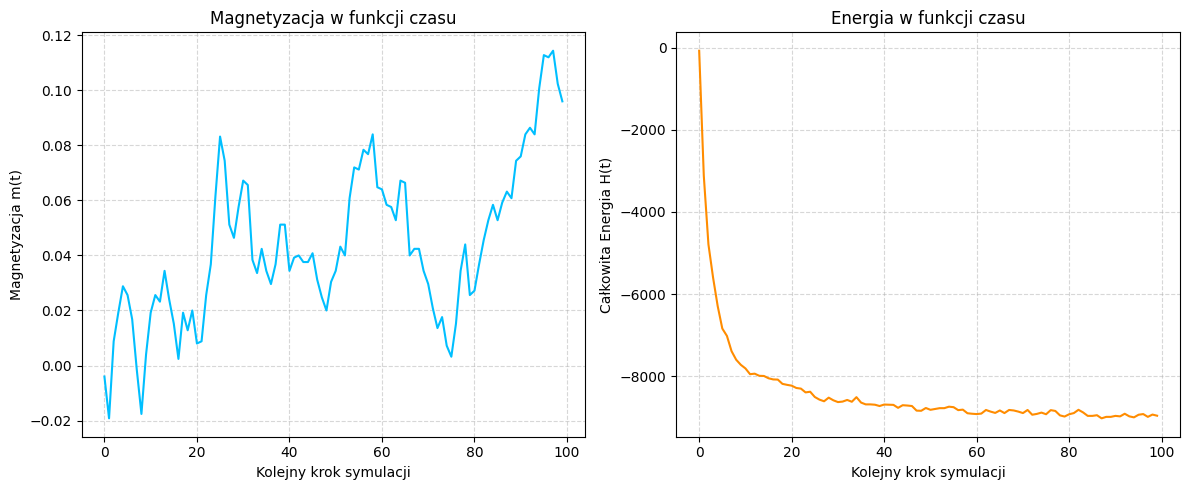

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wykres 1 - magnetyzacja
axes[0].plot(range(M), magnetizations, label = 'Magnetyzacja', color = 'deepskyblue')
axes[0].set_xlabel('Kolejny krok symulacji')
axes[0].set_ylabel('Magnetyzacja m(t)')
axes[0].set_title('Magnetyzacja w funkcji czasu')
axes[0].grid(True, linestyle = '--', alpha = 0.5)

# Wykres 2 - energia
axes[1].plot(range(M), energies, label = 'Energia', color = 'darkorange')
axes[1].set_xlabel('Kolejny krok symulacji')
axes[1].set_ylabel('Całkowita Energia H(t)')
axes[1].set_title('Energia w funkcji czasu')
axes[1].grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

In [38]:
# Animacja ewolucji spinów
fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
ax_anim.set_title("Ewolucja spinów (Model Isinga)")
img = ax_anim.imshow(grids_history[0], cmap='winter', interpolation='nearest', vmin=-1, vmax=1)
ax_anim.axis('off')

def update(frame):
    img.set_data(grids_history[frame])
    return [img]

anim = FuncAnimation(fig_anim, update, frames=M, interval=100, blit=True)

plt.close(fig_anim)

HTML(anim.to_jshtml())